In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tritonoa.data.reader import read_hdf5
from scipy.signal import find_peaks, find_peaks_cwt, hilbert

from vineyard.config import get_path

In [ ]:
streams = {}
for name in ["3dvha", "vla1", "vla2"]:
    # streams[name], channel = read_hdf5(get_path("denoised_data") / f"{name}.h5"), 1
    streams[name], channel = read_hdf5(get_path("pulse_comp_data") / f"{name}_pc.h5").trim(starttime=np.datetime64("2023-12-01T22:14:00")), 0

In [ ]:
fig, axes = plt.subplots(nrows=3, sharex=True, figsize=(24, 6))

for ax, (name, ds) in zip(axes, streams.items()):
    ax.plot(ds.time_vector, ds.data[channel], label=name)

ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

Processing 3dvha with height 0.1
Found 114 peaks
Processing vla1 with height 0.15
Found 58 peaks
Processing vla2 with height 0.15
Found 60 peaks


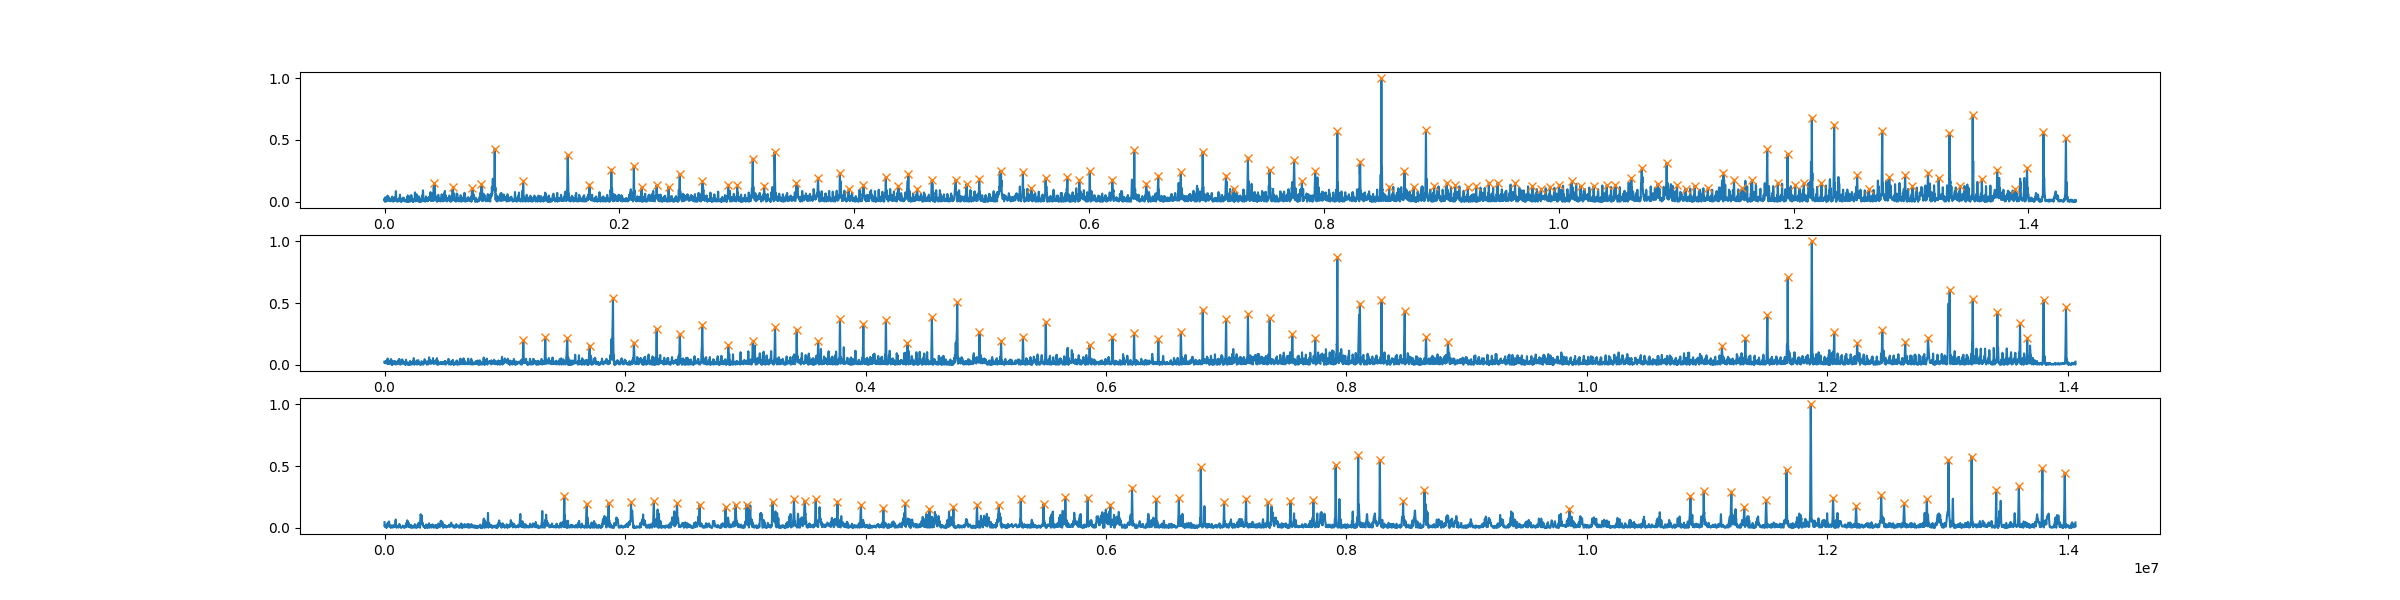

In [60]:
heights = [0.1, 0.15, 0.15]

fig, axes = plt.subplots(nrows=3, figsize=(24, 6))

for ax, height, (name, ds) in zip(axes, heights, streams.items()):
    print(f"Processing {name} with height {height}")
    data = np.abs(hilbert(streams[name].copy().data[channel]))
    peaks, _ = find_peaks(data, distance=3 * ds.stats.sampling_rate, height=height)
    print(f"Found {len(peaks)} peaks")

    ax.plot(data)
    ax.plot(peaks, data[peaks], "x")

plt.show()

In [ ]:
plt.close("all")